# Traffic Congestion Recommendations System Based On Climate Condition

**Authored by:** Quang An Quoc Tran  

**Duration:** 180 mins  

**Level:** Intermediate  

**Pre-requisite Skills:** Python, Data wrangling, Machine Learning

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import folium

from scipy import stats
from sklearn.neighbors import BallTree
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix

## 2. Read Data

In [2]:
# 1. READ ALL TRANSPORT FILES + MICRO DATA
transport_files = [
    "datasets/TransportActivityCount_2025_1.csv",
    "datasets/TransportActivityCount_2025_2.csv",
    "datasets/TransportActivityCount_2025_3.csv",
    "datasets/TransportActivityCount_2025_4.csv",
]

transport_list = [pd.read_csv(file) for file in transport_files]
transport_df = pd.concat(transport_list, ignore_index=True)

micro_df = pd.read_csv("datasets/microclimate-sensors-data.csv")

print("Transport shape:", transport_df.shape)
print("Micro shape:", micro_df.shape)

Transport shape: (5421538, 8)
Micro shape: (346990, 16)


- The transport dataset is extremely large (~5.4M rows), while the microclimate dataset is much smaller (~347K rows).
- This imbalance suggests that spatial-temporal alignment and aggregation will be critical to avoid noisy joins.

In [3]:
transport_df

,countLocationId,countLocationName,CountLocationLat,CountLocationLong,from,to,class,count
0,51228,Yarra Promenade - East Path,-37.821459,144.960343,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,313
1,45217,Royal Park Tram Track- CoM Pole 2773,-37.791020,144.949562,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,1
2,43775,Swanston St Asset ID: COM1757,-37.808159,144.963052,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,cyclist,1
3,44864,Royal Park Asset ID:COM2705,-37.795462,144.952063,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,2
4,51281,Yarra Promenade - West Path,-37.822354,144.958747,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,61
...,...,...,...,...,...,...,...,...
5421533,45471,La Trobe St- William St I-Hub,-37.811920,144.956251,2025-09-22T23:30:00.000Z,2025-09-22T23:35:00.000Z,car,18
5421534,43772,Southbank Prom Asset ID: COM1598,-37.820176,144.965092,2025-09-22T23:55:00.000Z,2025-09-23T00:00:00.000Z,pedestrian,4
5421535,47018,CoM pole 1112,-37.818470,144.971931,2025-09-22T23:40:00.000Z,2025-09-22T23:45:00.000Z,pedestrian,2
5421536,45473,La Trobe St- William St I-Hub,-37.811920,144.956251,2025-09-22T23:25:00.000Z,2025-09-22T23:30:00.000Z,cyclist,2


The transport data contains high-frequency movement records across multiple locations and transport classes, providing a detailed view of urban mobility patterns over time.

In [4]:
micro_df

,Device_id,Time,SensorLocation,LatLong,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise
0,ICTMicroclimate-09,2025-11-16T13:17:20+11:00,SkyFarm (Jeff's Shed). Rooftop - Melbourne Con...,"-37.8223306, 144.9521696",0.0,308.0,359.0,0.0,1.9,6.6,15.6,71.6,1000.100000,1.0,1.0,55.600000
1,ICTMicroclimate-06,2025-11-16T03:17:34+11:00,Tram Stop 7B - Melbourne Tennis Centre Precinc...,"-37.8194993, 144.9787211",0.0,271.0,359.0,0.0,0.4,2.0,15.2,78.9,1001.900000,2.0,3.0,57.000000
2,ICTMicroclimate-03,2025-11-16T13:14:29+11:00,CH1 rooftop,"-37.8140348, 144.96728",0.0,356.0,350.0,0.0,0.8,1.9,15.7,79.0,995.700000,2.0,4.0,61.400000
3,ICTMicroclimate-03,2025-08-18T01:10:39+10:00,CH1 rooftop,"-37.8140348, 144.96728",169.0,183.0,193.0,1.5,1.7,2.2,9.1,71.8,1018.900000,1.0,3.0,74.700000
4,ICTMicroclimate-01,2025-11-16T03:23:06+11:00,Birrarung Marr Park - Pole 1131,"-37.8185931, 144.9716404",NaN,341.0,NaN,NaN,0.2,NaN,14.6,89.0,1000.900024,6.0,9.0,47.599998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346985,ICTMicroclimate-03,2025-11-16T04:13:18+11:00,CH1 rooftop,"-37.8140348, 144.96728",0.0,250.0,269.0,0.0,0.5,0.9,14.6,90.0,995.900000,13.0,15.0,62.500000
346986,ICTMicroclimate-09,2025-11-16T03:46:04+11:00,SkyFarm (Jeff's Shed). Rooftop - Melbourne Con...,"-37.8223306, 144.9521696",0.0,6.0,359.0,0.0,0.4,2.6,14.7,80.5,1000.700000,16.0,18.0,57.000000
346987,ICTMicroclimate-08,2025-11-16T04:04:11+11:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,309.0,359.0,0.0,0.7,2.8,14.8,79.1,1001.900000,11.0,11.0,67.900000
346988,ICTMicroclimate-02,2025-11-16T04:04:46+11:00,101 Collins St L11 Rooftop,"-37.814604, 144.9702991",0.0,295.0,355.0,0.0,0.8,1.6,14.9,89.7,996.800000,15.0,17.0,68.400000


The microclimate dataset includes diverse environmental variables such as temperature, humidity, wind, pollution, and noise, which can be used to examine their relationship with congestion.

## 3. Merge Dataset

In [5]:
# 2. PARSE DATETIME
transport_df["from"] = pd.to_datetime(transport_df["from"], utc=True, errors="coerce")
transport_df["to"] = pd.to_datetime(transport_df["to"], utc=True, errors="coerce")
micro_df["Time"] = pd.to_datetime(micro_df["Time"], utc=True, errors="coerce")

transport_df["from_melb"] = transport_df["from"].dt.tz_convert("Australia/Melbourne")
transport_df["to_melb"] = transport_df["to"].dt.tz_convert("Australia/Melbourne")
micro_df["Time_melb"] = micro_df["Time"].dt.tz_convert("Australia/Melbourne")

# 3. KEEP ONLY OVERLAPPED TIME RANGE
start_time = transport_df["from_melb"].min()
end_time = transport_df["to_melb"].max()

micro_df = micro_df[
    (micro_df["Time_melb"] >= start_time) &
    (micro_df["Time_melb"] <= end_time)
].copy()

# 4. SPLIT LAT/LONG FROM MICRO DATA
micro_df[["micro_lat", "micro_long"]] = micro_df["LatLong"].str.split(",", expand=True)
micro_df["micro_lat"] = pd.to_numeric(micro_df["micro_lat"].str.strip(), errors="coerce")
micro_df["micro_long"] = pd.to_numeric(micro_df["micro_long"].str.strip(), errors="coerce")
micro_df = micro_df.dropna(subset=["micro_lat", "micro_long"]).copy()

# 5. CREATE 1-HOUR TIME BIN IN UTC
transport_df["time_1h_utc"] = transport_df["from"].dt.floor("1h")
micro_df["time_1h_utc"] = micro_df["Time"].dt.floor("1h")

transport_df["time_1h"] = transport_df["time_1h_utc"].dt.tz_convert("Australia/Melbourne")
micro_df["time_1h"] = micro_df["time_1h_utc"].dt.tz_convert("Australia/Melbourne")

# 6. AGGREGATE MICRO DATA BY SENSOR + 1 HOUR
micro_agg = (
    micro_df.groupby(
        ["Device_id", "SensorLocation", "micro_lat", "micro_long", "time_1h_utc"],
        as_index=False
    )
    .agg({
        "AirTemperature": "mean",
        "RelativeHumidity": "mean",
        "AtmosphericPressure": "mean",
        "PM25": "mean",
        "PM10": "mean",
        "Noise": "mean",
        "AverageWindSpeed": "mean",
        "GustWindSpeed": "mean",
        "AverageWindDirection": "mean"
    })
)

micro_agg["time_1h"] = micro_agg["time_1h_utc"].dt.tz_convert("Australia/Melbourne")

# 7. GET UNIQUE TRANSPORT LOCATIONS
transport_locations = (
    transport_df[["countLocationId", "countLocationName", "CountLocationLat", "CountLocationLong"]]
    .drop_duplicates()
    .dropna(subset=["CountLocationLat", "CountLocationLong"])
    .reset_index(drop=True)
)

sensor_locations = (
    micro_agg[["Device_id", "SensorLocation", "micro_lat", "micro_long"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# 8. FIND NEAREST SENSOR FOR EACH TRANSPORT LOCATION
transport_coords = np.radians(
    transport_locations[["CountLocationLat", "CountLocationLong"]].to_numpy()
)
sensor_coords = np.radians(
    sensor_locations[["micro_lat", "micro_long"]].to_numpy()
)

tree = BallTree(sensor_coords, metric="haversine")
dist, ind = tree.query(transport_coords, k=1)

transport_locations["nearest_sensor_idx"] = ind.flatten()
transport_locations["distance_km"] = dist.flatten() * 6371

sensor_locations = sensor_locations.reset_index().rename(columns={"index": "nearest_sensor_idx"})

transport_locations = transport_locations.merge(
    sensor_locations,
    on="nearest_sensor_idx",
    how="left"
)

# 9. MAP NEAREST SENSOR TO TRANSPORT DATA
transport_with_sensor = transport_df.merge(
    transport_locations[[
        "countLocationId",
        "countLocationName",
        "CountLocationLat",
        "CountLocationLong",
        "Device_id",
        "SensorLocation",
        "distance_km"
    ]],
    on=["countLocationId", "countLocationName", "CountLocationLat", "CountLocationLong"],
    how="left"
)

# 10. FILTER TOO FAR SENSOR FIRST
transport_with_sensor = transport_with_sensor[
    transport_with_sensor["distance_km"] <= 1.0
].copy()

# 11. AGGREGATE TRANSPORT DATA BY LOCATION + TIME + CLASS
transport_agg = (
    transport_with_sensor.groupby(
        [
            "time_1h_utc",
            "countLocationId",
            "countLocationName",
            "CountLocationLat",
            "CountLocationLong",
            "class",
            "Device_id",
            "SensorLocation",
            "distance_km"
        ],
        as_index=False
    )
    .agg({
        "count": "sum"
    })
)

transport_agg["time_1h"] = transport_agg["time_1h_utc"].dt.tz_convert("Australia/Melbourne")

# 12. MERGE TRANSPORT_AGG WITH MICRO_AGG
merged = transport_agg.merge(
    micro_agg,
    on=["Device_id", "SensorLocation", "time_1h_utc"],
    how="left",
    suffixes=("", "_micro")
)

# 13. REMOVE ROWS WITH TOO MANY NaNs
merged_df = merged[merged.isna().sum(axis=1) <= 8].copy()

# 14. KEEP MEANINGFUL COLUMNS
cols_keep = [
    "time_1h",
    "time_1h_utc",
    "countLocationId",
    "countLocationName",
    "CountLocationLat",
    "CountLocationLong",
    "class",
    "count",
    "Device_id",
    "SensorLocation",
    "distance_km",
    "AirTemperature",
    "RelativeHumidity",
    "AtmosphericPressure",
    "PM25",
    "PM10",
    "Noise",
    "AverageWindSpeed",
    "GustWindSpeed",
    "AverageWindDirection"
]

merged_df = merged_df[[c for c in cols_keep if c in merged_df.columns]].copy()

# 15. SAVE FILE
merged_df.to_csv("datasets/transport_micro_merged.csv", index=False)

print("\nSaved file: datasets/transport_micro_merged.csv")


Saved file: datasets/transport_micro_merged.csv


In [6]:
merged_df

,time_1h,time_1h_utc,countLocationId,countLocationName,CountLocationLat,CountLocationLong,class,count,Device_id,SensorLocation,distance_km,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise,AverageWindSpeed,GustWindSpeed,AverageWindDirection
0,2025-01-01 11:00:00+11:00,2025-01-01 00:00:00+00:00,43772,Southbank Prom Asset ID: COM1598,-37.820176,144.965092,cyclist,2,ICTMicroclimate-08,Swanston St - Tram Stop 13 adjacent Federation...,0.308744,18.600,59.475,1015.75,1.00,2.00,71.075,1.8,6.525,187.25
1,2025-01-01 11:00:00+11:00,2025-01-01 00:00:00+00:00,43772,Southbank Prom Asset ID: COM1598,-37.820176,144.965092,pedestrian,5675,ICTMicroclimate-08,Swanston St - Tram Stop 13 adjacent Federation...,0.308744,18.600,59.475,1015.75,1.00,2.00,71.075,1.8,6.525,187.25
2,2025-01-01 11:00:00+11:00,2025-01-01 00:00:00+00:00,43775,Swanston St Asset ID: COM1757,-37.808159,144.963052,cyclist,30,ICTMicroclimate-03,CH1 rooftop,0.751539,17.900,67.350,1010.30,3.75,6.25,74.650,1.8,2.375,177.00
3,2025-01-01 11:00:00+11:00,2025-01-01 00:00:00+00:00,43775,Swanston St Asset ID: COM1757,-37.808159,144.963052,pedestrian,20,ICTMicroclimate-03,CH1 rooftop,0.751539,17.900,67.350,1010.30,3.75,6.25,74.650,1.8,2.375,177.00
4,2025-01-01 11:00:00+11:00,2025-01-01 00:00:00+00:00,43891,Swanston St Asset ID: COM1757,-37.808159,144.963052,pedestrian,4,ICTMicroclimate-03,CH1 rooftop,0.751539,17.900,67.350,1010.30,3.75,6.25,74.650,1.8,2.375,177.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618062,2025-12-31 23:00:00+11:00,2025-12-31 12:00:00+00:00,58097,Clarendon St - Portable sensor -1,-37.809397,144.983715,motorbike,7,ICTMicroclimate-11,1 Treasury Place,0.851675,14.925,76.275,1010.40,2.00,7.50,70.675,2.1,8.100,158.25
618063,2025-12-31 23:00:00+11:00,2025-12-31 12:00:00+00:00,58097,Clarendon St - Portable sensor -1,-37.809397,144.983715,pedestrian,3,ICTMicroclimate-11,1 Treasury Place,0.851675,14.925,76.275,1010.40,2.00,7.50,70.675,2.1,8.100,158.25
618064,2025-12-31 23:00:00+11:00,2025-12-31 12:00:00+00:00,58097,Clarendon St - Portable sensor -1,-37.809397,144.983715,rigid,1,ICTMicroclimate-11,1 Treasury Place,0.851675,14.925,76.275,1010.40,2.00,7.50,70.675,2.1,8.100,158.25
618065,2025-12-31 23:00:00+11:00,2025-12-31 12:00:00+00:00,58097,Clarendon St - Portable sensor -1,-37.809397,144.983715,taxi,3,ICTMicroclimate-11,1 Treasury Place,0.851675,14.925,76.275,1010.40,2.00,7.50,70.675,2.1,8.100,158.25


The final aggregated dataset converts raw traffic activity into a congestion score and binary congestion label, making the problem suitable for predictive modeling and classification tasks.

## 4. Data Preprocessing

### 4.1 Create Target

In [7]:
# 1. LOAD MERGED DATA
df = pd.read_csv("datasets/transport_micro_merged.csv")

df["time_1h"] = pd.to_datetime(df["time_1h"], errors="coerce")

# 2. CLASS WEIGHT
class_weights = {
    'pedestrian': 0.15,
    'cyclist': 0.20,
    'escooter': 0.25,
    'motorbike': 0.60,
    'car': 1.00,
    'taxi': 1.00,
    'van': 1.20,
    'minibus': 1.50,
    'bus': 2.00,
    'rigid': 2.20,
    'truck': 2.50,
    'emergency_car': 1.20,
    'emergency_van': 1.40,
    'fire_engine': 2.80
}

df["class_weight"] = df["class"].map(class_weights).fillna(1.0)
df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0)

# 3. COMPUTE SCORE PER ROW
df["weighted_count"] = df["count"] * df["class_weight"]

# 4. AGGREGATTION
sensor_cols = [
    "AirTemperature",
    "RelativeHumidity",
    "AtmosphericPressure",
    "PM25",
    "PM10",
    "Noise",
    "AverageWindSpeed",
    "GustWindSpeed",
    "AverageWindDirection"
]

agg_dict = {
    "countLocationName": "first",
    "SensorLocation": "first",
    "CountLocationLat": "first",
    "CountLocationLong": "first",
    "Device_id": "first",
    "weighted_count": "sum"
}

for col in sensor_cols:
    if col in df.columns:
        agg_dict[col] = "mean"

agg_df = df.groupby(
    ["countLocationId", "time_1h"],
    as_index=False
).agg(agg_dict)

agg_df = agg_df.rename(columns={"weighted_count": "congestion_score"})

# 5. ADAPTIVE THRESHOLD PER LOCATION
thresholds = agg_df.groupby("countLocationId")["congestion_score"] \
                   .quantile(0.70).reset_index()

thresholds = thresholds.rename(columns={"congestion_score": "threshold_p70"})

agg_df = agg_df.merge(thresholds, on="countLocationId", how="left")

# 6. BINARY LABEL
agg_df["is_congested"] = (
    agg_df["congestion_score"] >= agg_df["threshold_p70"]
).astype(int)

# 7. FINAL OUTPUT
final_df = agg_df.sort_values(
    ["countLocationId", "time_1h"]
).reset_index(drop=True)

final_df

C:\Users\tranq\AppData\Local\Temp\ipykernel_30488\4073138593.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["time_1h"] = pd.to_datetime(df["time_1h"], errors="coerce")


,countLocationId,time_1h,countLocationName,SensorLocation,CountLocationLat,CountLocationLong,Device_id,congestion_score,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise,AverageWindSpeed,GustWindSpeed,AverageWindDirection,threshold_p70,is_congested
0,43772,2025-01-01 11:00:00+11:00,Southbank Prom Asset ID: COM1598,Swanston St - Tram Stop 13 adjacent Federation...,-37.820176,144.965092,ICTMicroclimate-08,851.65,18.600,59.475,1015.75,1.00,2.00,71.075,1.800,6.525,187.25,279.550,1
1,43772,2025-01-01 12:00:00+11:00,Southbank Prom Asset ID: COM1598,Swanston St - Tram Stop 13 adjacent Federation...,-37.820176,144.965092,ICTMicroclimate-08,710.75,19.100,56.900,1015.60,1.50,3.00,72.875,2.100,6.950,161.00,279.550,1
2,43772,2025-01-01 13:00:00+11:00,Southbank Prom Asset ID: COM1598,Swanston St - Tram Stop 13 adjacent Federation...,-37.820176,144.965092,ICTMicroclimate-08,281.00,19.525,52.200,1015.10,2.00,4.00,76.050,2.075,6.975,171.50,279.550,1
3,43772,2025-01-01 14:00:00+11:00,Southbank Prom Asset ID: COM1598,Swanston St - Tram Stop 13 adjacent Federation...,-37.820176,144.965092,ICTMicroclimate-08,119.55,19.900,51.550,1015.10,2.00,4.00,83.750,3.175,7.850,168.25,279.550,0
4,43772,2025-01-01 15:00:00+11:00,Southbank Prom Asset ID: COM1598,Swanston St - Tram Stop 13 adjacent Federation...,-37.820176,144.965092,ICTMicroclimate-08,38.40,19.850,55.000,1015.40,2.00,4.00,82.075,2.650,7.425,170.25,279.550,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171483,58097,2025-12-31 19:00:00+11:00,Clarendon St - Portable sensor -1,1 Treasury Place,-37.809397,144.983715,ICTMicroclimate-11,166.55,15.775,70.300,1009.70,1.75,4.25,65.975,3.000,7.725,177.25,306.875,0
171484,58097,2025-12-31 20:00:00+11:00,Clarendon St - Portable sensor -1,1 Treasury Place,-37.809397,144.983715,ICTMicroclimate-11,219.25,15.450,72.850,1010.30,1.75,2.50,75.400,3.025,7.700,156.25,306.875,0
171485,58097,2025-12-31 21:00:00+11:00,Clarendon St - Portable sensor -1,1 Treasury Place,-37.809397,144.983715,ICTMicroclimate-11,236.15,15.175,75.175,1010.70,99.25,111.25,82.025,2.400,8.550,165.75,306.875,0
171486,58097,2025-12-31 22:00:00+11:00,Clarendon St - Portable sensor -1,1 Treasury Place,-37.809397,144.983715,ICTMicroclimate-11,269.75,15.025,75.000,1010.75,2.00,5.50,76.950,2.275,9.350,153.00,306.875,0


### 4.2 Data Cleaning

In [8]:
final_df.describe()

,countLocationId,CountLocationLat,CountLocationLong,congestion_score,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise,AverageWindSpeed,GustWindSpeed,AverageWindDirection,threshold_p70,is_congested
count,171488.000000,171488.000000,171488.000000,171488.000000,171488.000000,171488.000000,171488.000000,139170.000000,139170.000000,139170.000000,171488.000000,159928.000000,171488.000000,171488.000000,171488.000000
mean,46445.188130,-37.811809,144.957946,119.171186,16.133642,70.034269,1013.508384,5.729088,8.073830,68.615931,0.596831,1.712303,139.965632,146.559505,0.300528
std,2968.635319,0.010106,0.006661,204.074973,5.633957,18.292897,8.137093,11.090527,11.613974,6.688640,0.619721,1.593297,101.093890,192.124269,0.458489
min,43772.000000,-37.823917,144.945772,0.150000,0.200000,4.525000,986.850000,0.000000,0.000000,44.350000,0.000000,0.000000,0.000000,2.850000,0.000000
25%,45038.000000,-37.820855,144.952063,4.950000,12.175000,57.525000,1007.800000,1.500000,3.750000,67.575000,0.150000,0.675000,44.000000,19.650000,0.000000
50%,45471.000000,-37.811920,144.956251,30.450000,15.425000,71.875000,1013.750000,3.000000,5.250000,69.945000,0.450000,1.225000,140.000000,55.400000,0.000000
75%,47018.000000,-37.808159,144.961642,126.750000,19.250000,84.000000,1019.075000,6.000000,8.500000,72.300000,0.825000,2.200000,218.500000,226.915000,1.000000
max,58097.000000,-37.791020,144.983715,2026.000000,40.500000,99.650002,1034.300000,307.000000,308.000000,104.625000,5.950000,14.875000,359.000000,647.020000,1.000000


The descriptive statistics show that congestion_score is highly variable and right-skewed, indicating the presence of peak congestion periods and potential outliers.

#### NULL Value Handling

In [9]:
final_df.isna().sum()

countLocationId             0
time_1h                     0
countLocationName           0
SensorLocation              0
CountLocationLat            0
CountLocationLong           0
Device_id                   0
congestion_score            0
AirTemperature              0
RelativeHumidity            0
AtmosphericPressure         0
PM25                    32318
PM10                    32318
Noise                   32318
AverageWindSpeed            0
GustWindSpeed           11560
AverageWindDirection        0
threshold_p70               0
is_congested                0
dtype: int64

Missing values are concentrated in PM25, PM10, Noise, and GustWindSpeed, suggesting incomplete sensor readings in some time periods.

In [10]:
# FiILL MISSING VALUE USING LINEAR INTERPOLATION
final_df = final_df.sort_values(["countLocationId", "time_1h"])

cols_fill = ["PM25", "PM10", "Noise", "GustWindSpeed"]

final_df[cols_fill] = final_df.groupby("countLocationId")[cols_fill].transform(
    lambda x: x.interpolate(method="linear")
)

final_df[cols_fill] = final_df[cols_fill].fillna(final_df[cols_fill].median())

In [11]:
final_df.isna().sum()

countLocationId         0
time_1h                 0
countLocationName       0
SensorLocation          0
CountLocationLat        0
CountLocationLong       0
Device_id               0
congestion_score        0
AirTemperature          0
RelativeHumidity        0
AtmosphericPressure     0
PM25                    0
PM10                    0
Noise                   0
AverageWindSpeed        0
GustWindSpeed           0
AverageWindDirection    0
threshold_p70           0
is_congested            0
dtype: int64

All missing values have been successfully handled, which improves data completeness and ensures the dataset is ready for downstream modeling.

In [12]:
final_df['is_congested'].value_counts()

is_congested
0    119951
1     51537
Name: count, dtype: int64

The target classes are moderately imbalanced, with non-congested cases occurring more frequently, which should be considered when selecting evaluation metrics and modeling techniques.

#### Outlier Handling

In [13]:
def cap_outliers(df, cols):
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[col] = df[col].clip(lower, upper)
    return df

cols = ["PM25", "PM10", "Noise", "GustWindSpeed", "congestion_score"]
final_df = cap_outliers(final_df, cols)

#### Data Exploration

In [14]:
# Time-based features
final_df["time_1h"] = pd.to_datetime(final_df["time_1h"], utc=True) \
                        .dt.tz_convert("Australia/Melbourne")

final_df["hour"] = final_df["time_1h"].dt.hour
final_df["day_of_week"] = final_df["time_1h"].dt.dayofweek
final_df["is_weekend"] = final_df["day_of_week"].isin([5, 6]).astype(int)

final_df["hour_sin"] = np.sin(2 * np.pi * final_df["hour"] / 24)
final_df["hour_cos"] = np.cos(2 * np.pi * final_df["hour"] / 24)

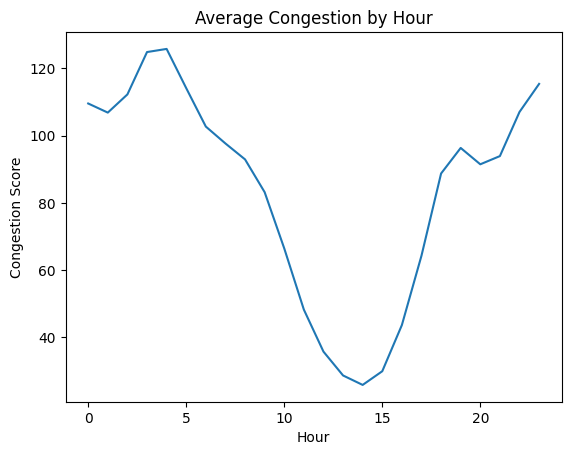

In [15]:
hourly = final_df.groupby("hour")["congestion_score"].mean()

sns.lineplot(x=hourly.index, y=hourly.values)
plt.title("Average Congestion by Hour")
plt.xlabel("Hour")
plt.ylabel("Congestion Score")
plt.show()

Congestion follows a clear daily cycle, with higher levels in the early morning and late evening, while midday shows the lowest average congestion.

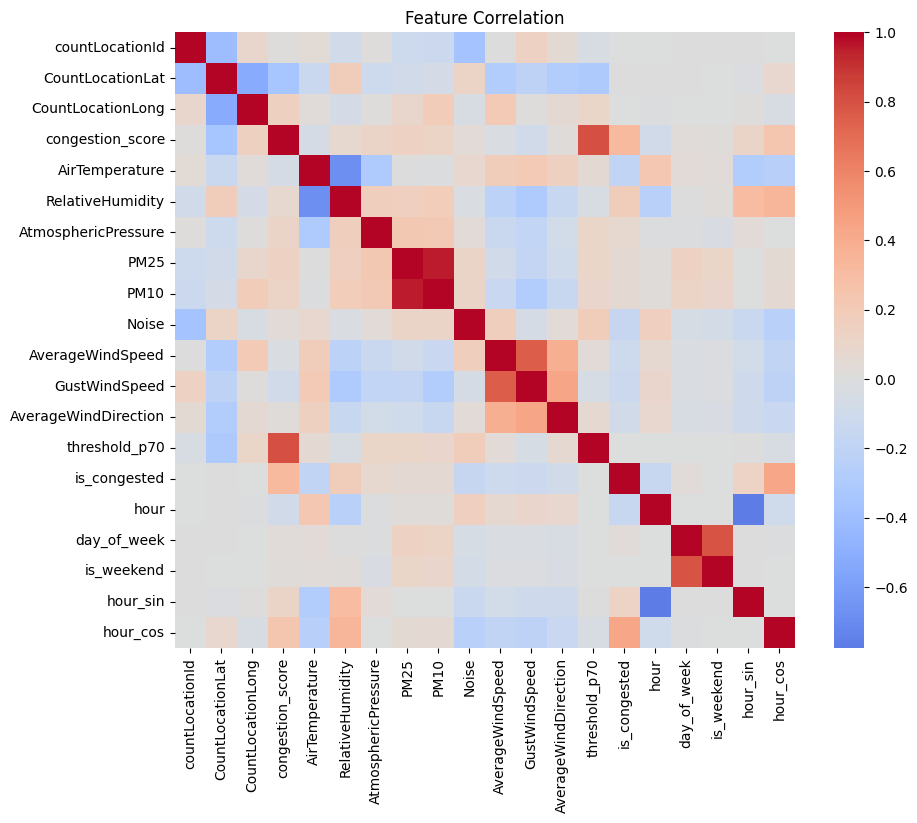

In [16]:
corr = final_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation")
plt.show()

The correlation matrix suggests that congestion is influenced by multiple variables, while some environmental features appear to have only weak linear relationships with the target.

In [17]:
final_df.to_csv('datasets/transport_micro_merged_clean.csv', index=False)
print("\nSaved file: datasets/transport_micro_merged_clean.csv")


Saved file: datasets/transport_micro_merged_clean.csv


## 5. Model Prediction

In [18]:
# 1. LOAD DATA
df = pd.read_csv("datasets/transport_micro_merged_clean.csv")

# Convert datetime
df["time_1h"] = pd.to_datetime(df["time_1h"], utc=True)

# Sort by time for time-series modeling
df = df.sort_values("time_1h").reset_index(drop=True)

# 2. SELECT NUMERIC FEATURES
target = "is_congested"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target and leakage columns
leakage_cols = [
    "is_congested",
    "threshold_p70",
    "congestion_score",
    "countLocationId",
    "hour",
    "day_of_week",
]

features = [col for col in numeric_cols if col not in leakage_cols]

X = df[features]
y = df[target]

# 3. TRAIN-TEST SPLIT (TIME-SERIES)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# 4. SCALING FOR LOGISTIC REGRESSION
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. LOGISTIC REGRESSION
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# 6. RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 7. MODEL COMPARISON
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

Train size: (137190, 14)
Test size: (34298, 14)
LOGISTIC REGRESSION RESULTS
Accuracy: 0.688873986821389
ROC-AUC: 0.7680521106274777

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.66      0.76     25414
           1       0.44      0.77      0.56      8884

    accuracy                           0.69     34298
   macro avg       0.67      0.71      0.66     34298
weighted avg       0.77      0.69      0.71     34298

RANDOM FOREST RESULTS
Accuracy: 0.7711819931191323
ROC-AUC: 0.8240169559319639

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85     25414
           1       0.56      0.54      0.55      8884

    accuracy                           0.77     34298
   macro avg       0.70      0.70      0.70     34298
weighted avg       0.77      0.77      0.77     34298

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.688874  0.768052
1

The Logistic Regression model achieved an accuracy of 0.69 and ROC-AUC of 0.77, indicating moderate performance. It showed high recall for the congested class (0.77), meaning it was effective at identifying congestion events, but at the cost of low precision (0.44), resulting in a higher number of false positives.

In contrast, the Random Forest model significantly outperformed Logistic Regression, achieving an accuracy of 0.77 and ROC-AUC of 0.82. It provided a more balanced performance across both classes, with improved precision (0.56) and reasonable recall (0.54) for the congested class. Additionally, the overall F1-score and class-wise balance indicate that Random Forest captures complex, non-linear relationships in the data more effectively.

Overall, Random Forest is the preferred model for this task, as it delivers higher predictive performance and a better balance between detecting congestion and minimizing false alarms.

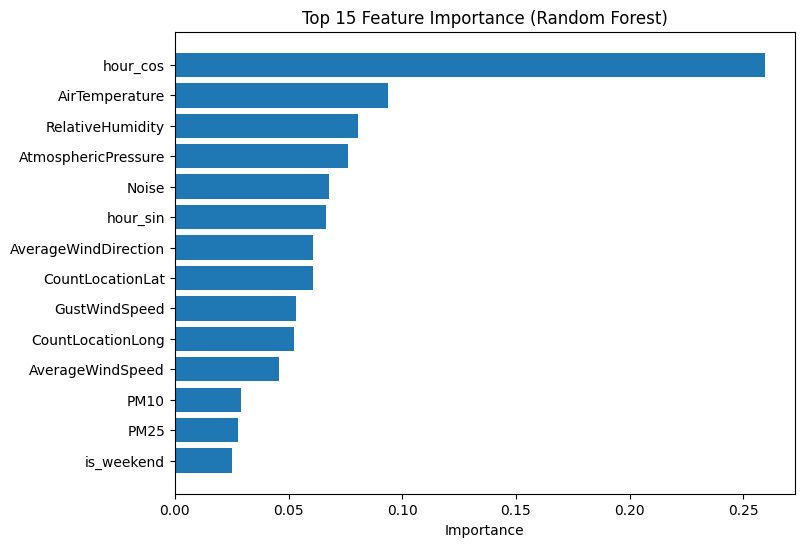

In [19]:
# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

The results show that temporal features are the most influential in predicting congestion, with hour_cos dominating by a large margin. This confirms that traffic congestion strongly follows daily cyclical patterns, and that cyclical encoding (sin/cos) is more effective than using raw time variables. Environmental factors such as air temperature, relative humidity, and atmospheric pressure also play an important role, indicating that weather conditions contribute to variations in congestion levels.

Other features, including noise, wind-related variables, and spatial coordinates, provide moderate predictive value, capturing environmental and geographic differences. In contrast, pollution indicators (PM2.5, PM10) and the is_weekend feature have relatively low importance, suggesting a weaker direct impact on congestion. Overall, congestion is primarily driven by temporal patterns, with environmental factors acting as secondary contributors.